In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


df = pd.read_csv("retrospective_data_cleaned.csv")

#### Commodity Level Analysis

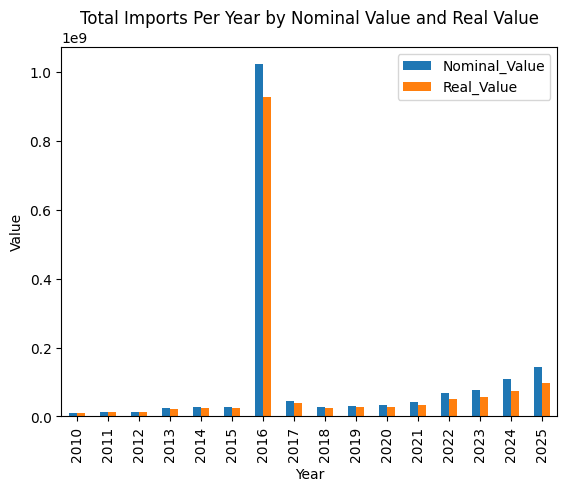

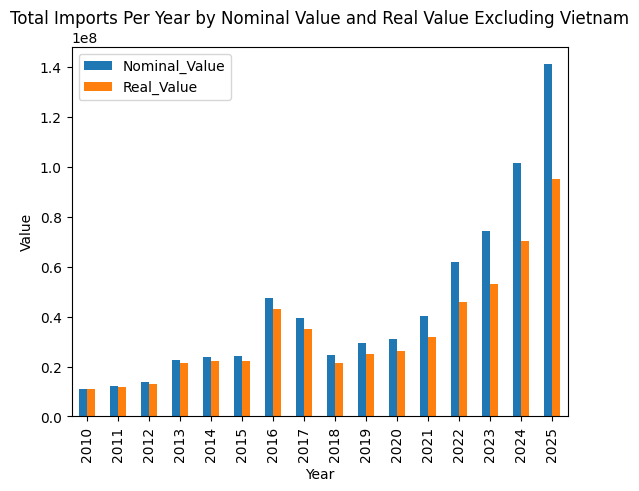

In [11]:
# Bar Plot of Total Imports per Year
yearly_total = (df.groupby("Year")[["Nominal_Value", "Real_Value"]].sum().sort_index())
yearly_total.plot(kind="bar", title="Total Imports Per Year by Nominal Value and Real Value")
plt.xlabel("Year")
plt.ylabel("Value")
plt.show()

# Without Vietnam
yearly_total_novietnam = (df[df["Countries"] != "Vietnam"].groupby("Year")[["Nominal_Value", "Real_Value"]].sum().sort_index())
yearly_total_novietnam.plot(kind="bar", title="Total Imports Per Year by Nominal Value and Real Value Excluding Vietnam")
plt.xlabel("Year")
plt.ylabel("Value")
plt.show()

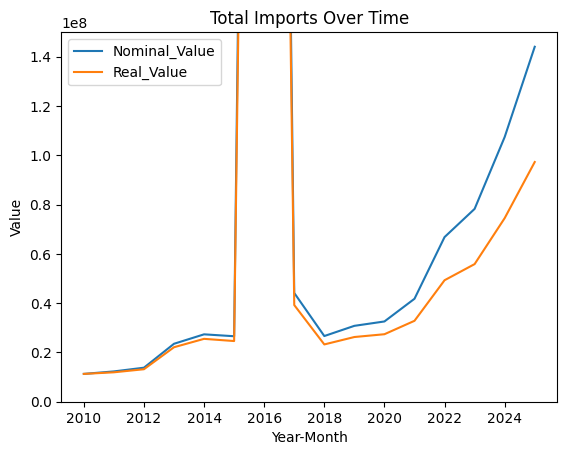

In [60]:
# Line Plot of Total Imports Per Year-Month
yearly_total2 = (df.groupby("YearMonth")[["Nominal_Value", "Real_Value"]].sum().sort_index())
yearly_total.plot(kind="line", title="Total Imports Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Value")
plt.ylim(0, 1.5e8)
plt.show()

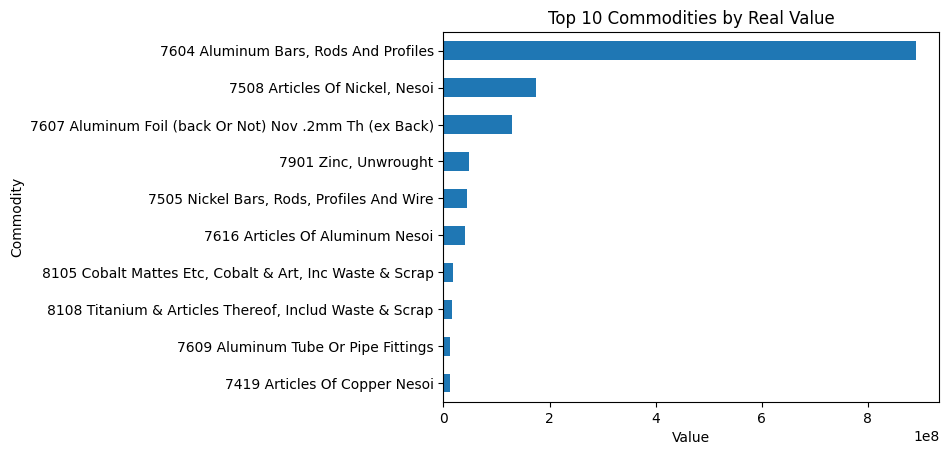

In [22]:
# Bar Plot of Top 10 Commodities by Real Value
commodity_totals = (df.groupby("Commodities")["Real_Value"].sum().sort_values(ascending=True))
top_10_commodities = commodity_totals.tail(10)
top_10_commodities.plot(kind="barh", title="Top 10 Commodities by Real Value")
plt.xlabel("Value")
plt.ylabel("Commodity")
plt.show()


In [44]:
# Percent Share of the Total Real Value for Top 5 Commodities
top_5_commodities = commodity_totals.tail(5).sort_values(ascending=False)
total_values = commodity_totals.sum()
percent_share = ((top_5_commodities / total_values) * 100).round(2)
percent_share = percent_share.astype(str) + '%'
percent_share.index.name=None
print("Percent Share of the Total Real Value for Top 5 Commodities:\n")
print(percent_share.to_string())


Percent Share of the Total Real Value for Top 5 Commodities:

7604 Aluminum Bars, Rods And Profiles                     60.91%
7508 Articles Of Nickel, Nesoi                             11.9%
7607 Aluminum Foil (back Or Not) Nov .2mm Th (ex Back)     8.87%
7901 Zinc, Unwrought                                       3.27%
7505 Nickel Bars, Rods, Profiles And Wire                   3.0%


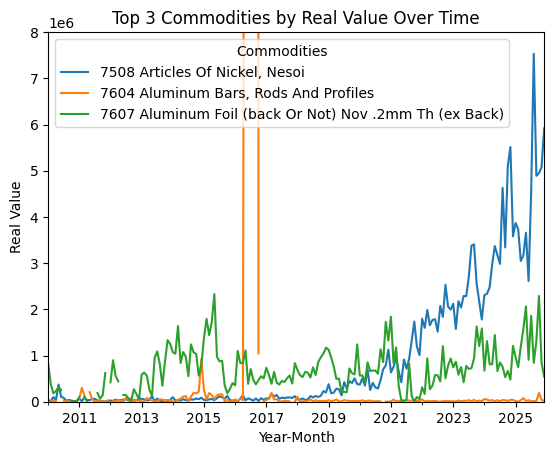

In [83]:
# Time Series Plot for Top 3 Commodities by Real Value
df["YearMonth"] = pd.to_datetime(df["YearMonth"])
top_3_commodities = df.groupby("Commodities")["Real_Value"].sum().sort_values(ascending=False).head(3)
df_top3 = df[df["Commodities"].isin(top_3_commodities.index)]
com_total_time = (df_top3.groupby(["YearMonth", "Commodities"])["Real_Value"].sum().unstack().sort_index())
com_total_time.plot(kind="line", title="Top 3 Commodities by Real Value Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Real Value")
plt.ylim(0, 0.8e7)
plt.show()

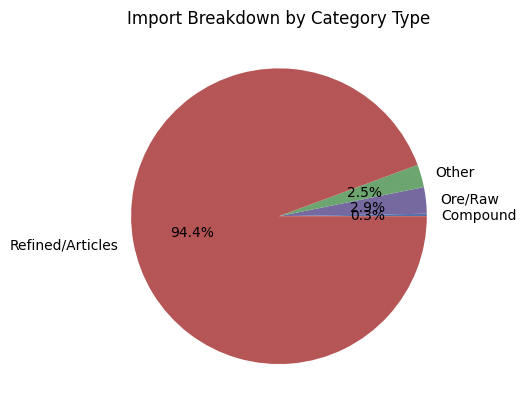

In [82]:
# Import Breakdown by Category Type
imports_by_category = df.groupby("CategoryType")["Real_Value"].sum()
imports_by_category.name = None
soft_colors = [
    "#5570ab",  # red
    "#7569a0",  # purple
    "#6ca570",  # orange
    "#b65555",  # blue
    "#d1875c",  # green
]
imports_by_category.plot(kind="pie", autopct="%1.1f%%", title="Import Breakdown by Category Type", colors=soft_colors)
plt.show()

Commodity Level Analysis Done
#### Country Level Analysis

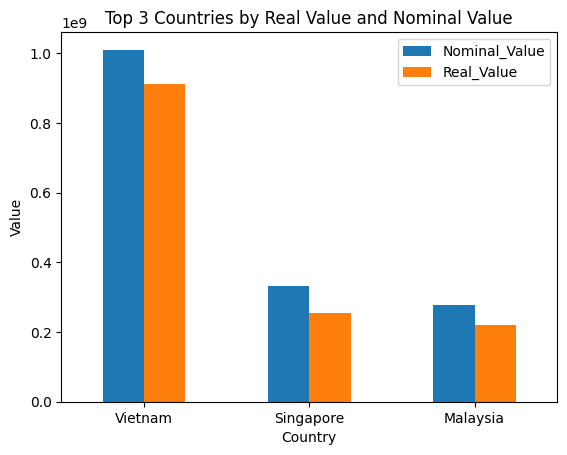

In [99]:
# Bar Plot of Top 3 Countries by Real Value and Nominal Value
country_total = (df.groupby("Countries")[["Nominal_Value", "Real_Value"]].sum().sort_values(by="Real_Value", ascending=False))
top_3_countries = country_total.head(3)
top_3_countries.plot(kind="bar", title="Top 3 Countries by Real Value and Nominal Value")
plt.xlabel("Country")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.show()

In [86]:
# Percent Share of the Total Real Value for Top 5 Countries
country_total_real = (df.groupby("Countries")["Real_Value"].sum().sort_values(ascending=False))
top_3_real = country_total_real.head(3)
total_values_country = country_total_real.sum()
percent_share_country = ((top_3_real / total_values_country) * 100).round(2)
percent_share_country = percent_share_country.astype(str) + '%'
percent_share_country.index.name=None
print("Percent Share of the Total Real Value for Top 3 Countries:\n")
print(percent_share_country.to_string())

Percent Share of the Total Real Value for Top 3 Countries:

Vietnam      62.44%
Singapore    17.45%
Malaysia     15.08%


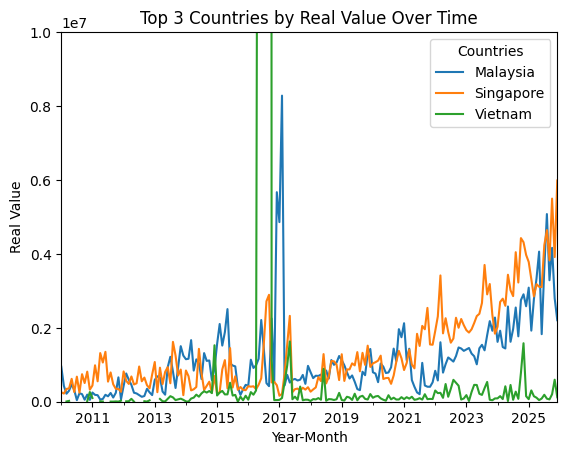

In [89]:
# Time Series Plot for Top 3 Countries by Real Value
df["YearMonth"] = pd.to_datetime(df["YearMonth"])
df_top3_country = df[df["Countries"].isin(top_3_real.index)]

country_time_series = (df_top3_country.groupby(["YearMonth", "Countries"])["Real_Value"].sum().unstack().sort_index())
country_time_series.plot(kind="line", title="Top 3 Countries by Real Value Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Real Value")
plt.ylim(0, 1.0e7)
plt.show()

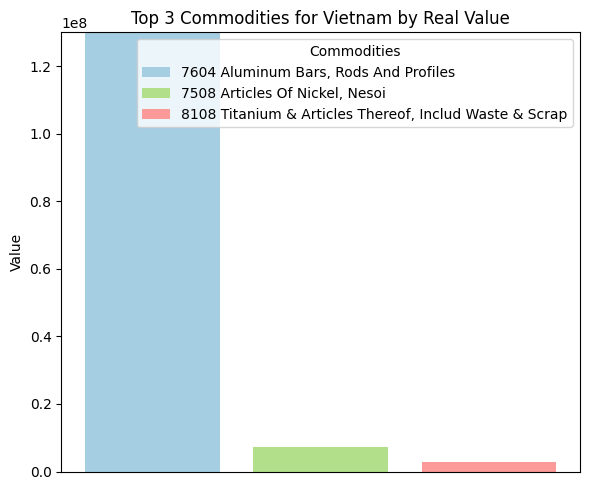

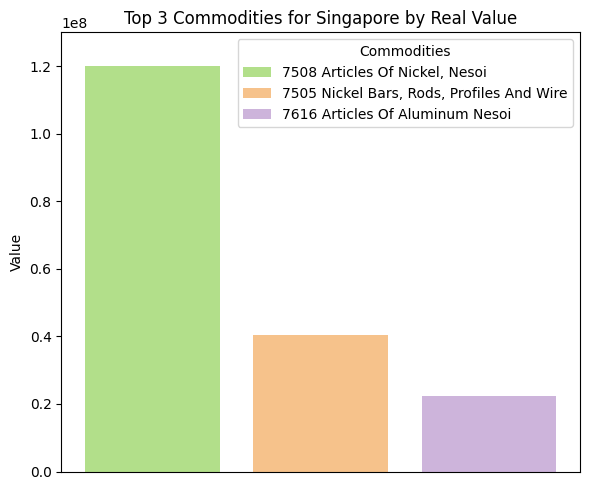

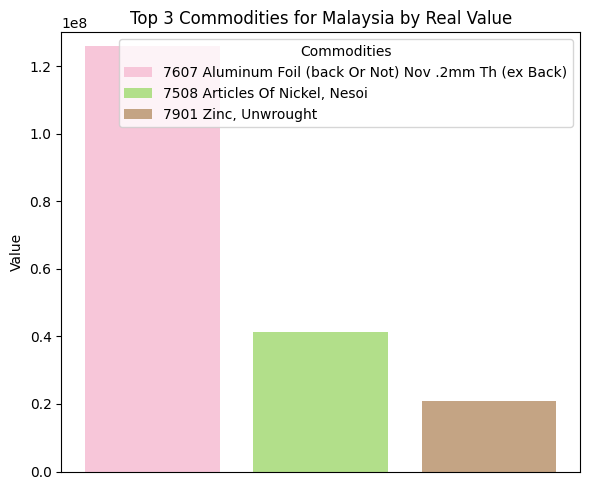

In [145]:
# Vietnam
vietnam_sub = df[df["Countries"] == "Vietnam"]
top_3_vietnam = (vietnam_sub.groupby("Commodities")["Real_Value"].sum().sort_values(ascending=False)).head(3)

colors = ["#a6cee3", "#b2df8a", "#fb9a99"]

plt.figure(figsize=(6,5))

bars = plt.bar(range(3),
               top_3_vietnam.values,
               color=colors)

plt.xticks([])

plt.legend(bars,
           top_3_vietnam.index,
           title="Commodities")

plt.title("Top 3 Commodities for Vietnam by Real Value")
plt.ylabel("Value")
plt.ylim(0,1.3e8)
plt.tight_layout()
plt.show()

# Singapore
singapore_sub = df[df["Countries"] == "Singapore"]
top_3_singapore = (singapore_sub.groupby("Commodities")["Real_Value"].sum().sort_values(ascending=False)).head(3)

colors = ["#b2df8a", "#f6c28b", "#cdb4db"]

plt.figure(figsize=(6,5))

bars2 = plt.bar(range(3),
               top_3_singapore.values,
               color=colors)

plt.xticks([])

plt.legend(bars2,
           top_3_singapore.index,
           title="Commodities")

plt.title("Top 3 Commodities for Singapore by Real Value")
plt.ylabel("Value")
plt.ylim(0,1.3e8)
plt.tight_layout()
plt.show()

# Malaysia
malaysia_sub = df[df["Countries"] == "Malaysia"]
top_3_malaysia = (malaysia_sub.groupby("Commodities")["Real_Value"].sum().sort_values(ascending=False)).head(3)

colors = ["#f7c6d9", "#b2df8a", "#c4a484"]

plt.figure(figsize=(6,5))

bars3 = plt.bar(range(3),
               top_3_malaysia.values,
               color=colors)

plt.xticks([])

plt.legend(bars3,
           top_3_malaysia.index,
           title="Commodities")

plt.title("Top 3 Commodities for Malaysia by Real Value")
plt.ylabel("Value")
plt.ylim(0,1.3e8)
plt.tight_layout()
plt.show()

Country Level Analysis Done